In [10]:
import pandas as pd 
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import numpy as np 
from models import PCA_Scratch

In [11]:
class NaiveBayes_Scratch:
    def __init__(self, model_type='gaussian'):
        self.model_type = model_type
        self.priors = {}
        self.parameters = {}
        self.classes = None

    def fit(self, X, y):
        n_samples, n_features = X.shape
        self.classes = np.unique(y)
        for c in self.classes:
            X_c = X[y == c]
            self.priors[c] = X_c.shape[0] / n_samples
            if self.model_type == 'gaussian':
                self.parameters[c] = {
                    "mean": X_c.mean(axis=0),
                    "var": X_c.var(axis=0) + 1e-9
                }
            else:
                self.parameters[c] = {
                    "probs": [(X_c[:, i] == 1).mean() for i in range(n_features)]
                }

    def predict(self, X):
        return np.array([self._predict_single(x) for x in X])

    def _predict_single(self, x):
        posteriors = []
        for c in self.classes:
            prior = np.log(self.priors[c])
            likelihood = np.sum(self._get_likelihood(c, x))
            posteriors.append(prior + likelihood)
        return self.classes[np.argmax(posteriors)]

    def _get_likelihood(self, class_idx, x):
        if self.model_type == 'gaussian':
            mean = self.parameters[class_idx]["mean"]
            var = self.parameters[class_idx]["var"]
            numerator = np.exp(-((x - mean) ** 2) / (2 * var))
            denominator = np.sqrt(2 * np.pi * var)    
            return np.log(numerator / denominator)
        else:
            probs = np.array(self.parameters[class_idx]["probs"])
            return x * np.log(probs + 1e-9) + (1 - x) * np.log(1 - probs + 1e-9)

In [12]:
df = pd.read_csv('data/Students Social Media Addiction.csv')

print("-- First 5 Rows ---")
print(df.head())

print("\n --- Missing Values ---")
print(df.isnull().sum)

-- First 5 Rows ---
   Student_ID  Age  Gender Academic_Level     Country  Avg_Daily_Usage_Hours  \
0           1   19  Female  Undergraduate  Bangladesh                    5.2   
1           2   22    Male       Graduate       India                    2.1   
2           3   20  Female  Undergraduate         USA                    6.0   
3           4   18    Male    High School          UK                    3.0   
4           5   21    Male       Graduate      Canada                    4.5   

  Most_Used_Platform Affects_Academic_Performance  Sleep_Hours_Per_Night  \
0          Instagram                          Yes                    6.5   
1            Twitter                           No                    7.5   
2             TikTok                          Yes                    5.0   
3            YouTube                           No                    7.0   
4           Facebook                          Yes                    6.0   

   Mental_Health_Score Relationship_Status

In [13]:
from sklearn.preprocessing import LabelEncoder

# 1. Separate our target (what we want to predict)
y = df['Addicted_Score'].values

# 2. Identify Categorical vs Numerical columns
categorical_cols = ['Gender', 'Academic_Level', 'Country', 'Most_Used_Platform', 
                    'Affects_Academic_Performance', 'Relationship_Status']

numerical_cols = ['Age', 'Avg_Daily_Usage_Hours', 'Sleep_Hours_Per_Night', 
                  'Mental_Health_Score', 'Conflicts_Over_Social_Media']

# 3. Convert Categorical Text to Numbers (Label Encoding) (0/1)
df_encoded = df.copy()
le = LabelEncoder()

for col in categorical_cols:
    df_encoded[col] = le.fit_transform(df[col])

# 4. Create our feature matrices
X_numerical = df_encoded[numerical_cols].values
X_categorical = df_encoded[categorical_cols].values

print("Numerical features shape:", X_numerical.shape)
print("Categorical features shape:", X_categorical.shape)

Numerical features shape: (705, 5)
Categorical features shape: (705, 6)


In [14]:
# Standardize the numerical data
# Formula: z = (x - mean) / std

X_mean = np.mean(X_numerical, axis=0)
X_std = np.std(X_numerical, axis=0)

# We use 1e-9 to avoid division by zero if a column has zero variance
X_numerical_scaled = (X_numerical - X_mean) / (X_std + 1e-9)

print("Scaled Numerical Data (first 2 rows):")
print(X_numerical_scaled[:2])

Scaled Numerical Data (first 2 rows):
[[-1.18691539  0.22385678 -0.32763788 -0.20552043  0.15706307]
 [ 0.95866243 -2.24330914  0.56042327  1.60562838 -2.97678961]]


In [17]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report

# 1. Use the PCA results as our features (X) and Addiction Score as target (y)
# We usually simplify the target into "High" vs "Low" addiction for Naive Bayes
y_binary = (y > 5).astype(int) 

X_train, X_test, y_train, y_test = train_test_split(X_pca, y_binary, test_size=0.2, random_state=42)

# 2. Initialize and Train
nb_model = NaiveBayes_Scratch(model_type='gaussian')
nb_model.fit(X_train, y_train)

# 3. Predict
y_pred = nb_model.predict(X_test)

# 4. Evaluate
print(f"Accuracy: {accuracy_score(y_test, y_pred)*100:.2f}%")
print("\nClassification Report:\n", classification_report(y_test, y_pred))

Accuracy: 97.87%

Classification Report:
               precision    recall  f1-score   support

           0       0.96      0.98      0.97        53
           1       0.99      0.98      0.98        88

    accuracy                           0.98       141
   macro avg       0.98      0.98      0.98       141
weighted avg       0.98      0.98      0.98       141



C:\Users\youss\AppData\Local\Temp\ipykernel_14132\1629406481.py:41: RuntimeWarning: divide by zero encountered in log
  return np.log(numerator / denominator)


--- EXPERIMENT 0: BASELINE RESULTS ---
Accuracy: 99.29%
              precision    recall  f1-score   support

           0       0.98      1.00      0.99        53
           1       1.00      0.99      0.99        88

    accuracy                           0.99       141
   macro avg       0.99      0.99      0.99       141
weighted avg       0.99      0.99      0.99       141



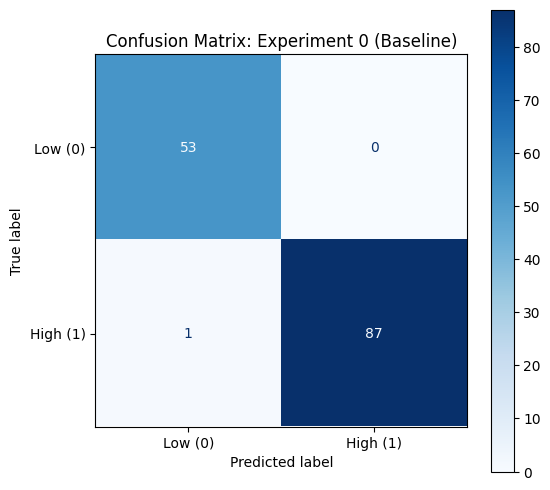

In [18]:
# Experiment 0 [Baseline]

# 1.Combining the numerical scaled values and the categorical values 
X_all = np.hstack((X_numerical_scaled, X_categorical))

# 2. Split the combined data
X_train_0, X_test_0, y_train_0, y_test_0 = train_test_split(X_all, y_binary, test_size=0.2, random_state=42)

# 3. Train
nb_baseline = NaiveBayes_Scratch(model_type='gaussian')
nb_baseline.fit(X_train_0, y_train_0)

# 4. Predict & Evaluate
y_pred_0 = nb_baseline.predict(X_test_0)

print("--- EXPERIMENT 0: BASELINE RESULTS ---")
print(f"Accuracy: {accuracy_score(y_test_0, y_pred_0)*100:.2f}%")
print(classification_report(y_test_0, y_pred_0))

# 5. Confusion Matrix using Matplotlib + Sklearn (No Seaborn required)
cm_0 = confusion_matrix(y_test_0, y_pred_0)
disp = ConfusionMatrixDisplay(confusion_matrix=cm_0, display_labels=['Low (0)', 'High (1)'])

# Plotting
fig, ax = plt.subplots(figsize=(6, 6))
disp.plot(ax=ax, cmap='Blues', values_format='d') # 'd' displays raw counts
plt.title('Confusion Matrix: Experiment 0 (Baseline)')
plt.show()

--- EXPERIMENT A: FEATURE SELECTION RESULTS ---
Accuracy: 99.29%

Classification Report:
               precision    recall  f1-score   support

           0       0.98      1.00      0.99        53
           1       1.00      0.99      0.99        88

    accuracy                           0.99       141
   macro avg       0.99      0.99      0.99       141
weighted avg       0.99      0.99      0.99       141



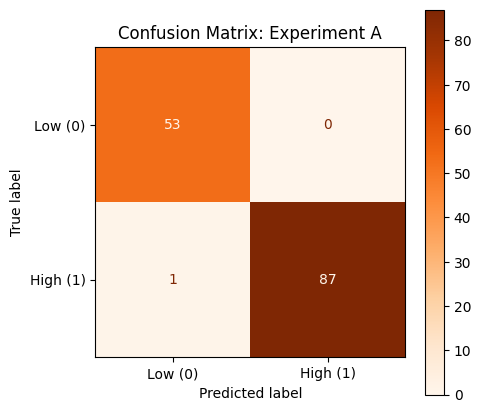

In [19]:
# Experiment A [feature selection + Naive Bayes]

# I have selected feature no.1 and no.4 [1: Avg_Daily_Usage_Hours, 4: Conflicts_Over_Social_Media]
X_selected = X_numerical_scaled[:, [1, 4]] 

# 7. Train using ONLY these features
X_train_A, X_test_A, y_train_A, y_test_A = train_test_split(X_selected, y_binary, test_size=0.2, random_state=42)

nb_A = NaiveBayes_Scratch(model_type='gaussian')
nb_A.fit(X_train_A, y_train_A)

# 8. Predict
y_pred_A = nb_A.predict(X_test_A)

# Evaluation 1: Accuracy
print("--- EXPERIMENT A: FEATURE SELECTION RESULTS ---")
print(f"Accuracy: {accuracy_score(y_test_A, y_pred_A)*100:.2f}%")

# Evaluation 2: Classification Report (Precision, Recall, F1)
print("\nClassification Report:\n", classification_report(y_test_A, y_pred_A))

# Evaluation 3: Confusion Matrix
cm_A = confusion_matrix(y_test_A, y_pred_A)
disp_A = ConfusionMatrixDisplay(confusion_matrix=cm_A, display_labels=['Low (0)', 'High (1)'])

# Using a different color (Oranges) to distinguish from the Baseline
fig, ax = plt.subplots(figsize=(5, 5))
disp_A.plot(ax=ax, cmap='Oranges', values_format='d')
plt.title('Confusion Matrix: Experiment A')
plt.show()

PCA with k=1 | Accuracy: 95.74%
PCA with k=2 | Accuracy: 96.45%
PCA with k=3 | Accuracy: 97.87%
PCA with k=4 | Accuracy: 97.87%

--- Final Evaluation for Best Performing k (3) ---

Classification Report:
               precision    recall  f1-score   support

           0       0.96      0.98      0.97        53
           1       0.99      0.98      0.98        88

    accuracy                           0.98       141
   macro avg       0.98      0.98      0.98       141
weighted avg       0.98      0.98      0.98       141



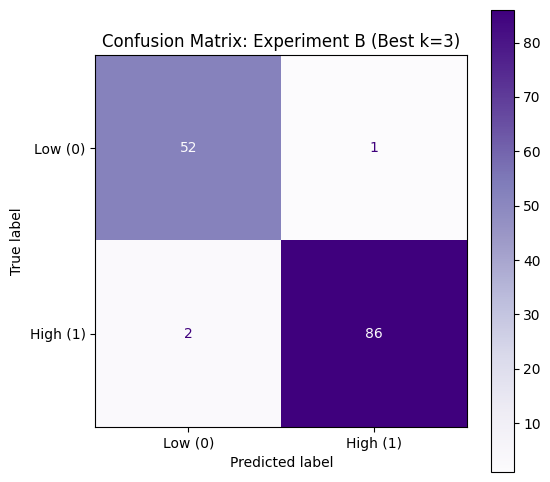

In [20]:
# Experiment B [PCA + Naive Bayes]

best_k = 0
best_acc = 0

for k in [1, 2, 3, 4]:
    # 1. Initialize the PCA with k components
    pca = PCA_Scratch(n_components= k)

    # 2. Fit and transform the numerical data
    X_pca = pca.fit_transform(X_numerical_scaled)

    # Train Naive Bayes
    X_tr, X_te, y_tr, y_te = train_test_split(X_pca, y_binary, test_size=0.2, random_state=42)
    model = NaiveBayes_Scratch(model_type='gaussian')
    model.fit(X_tr, y_tr)
    
    # Results
    y_pred = model.predict(X_te)
    acc = accuracy_score(y_te, y_pred)
    print(f"PCA with k={k} | Accuracy: {acc*100:.2f}%")
    
    # Keep track of the best performing k for the final evaluation
    if acc > best_acc:
        best_acc = acc
        best_k = k
        best_y_test = y_te
        best_y_pred = y_pred

# --- Evaluation of the best k ---
print(f"\n--- Final Evaluation for Best Performing k ({best_k}) ---")

# 1. Classification Report
print("\nClassification Report:\n", classification_report(best_y_test, best_y_pred))

# 2. Confusion Matrix
cm_B = confusion_matrix(best_y_test, best_y_pred)
disp_B = ConfusionMatrixDisplay(confusion_matrix=cm_B, display_labels=['Low (0)', 'High (1)'])

# Plotting the matrix
fig, ax = plt.subplots(figsize=(6, 6))
disp_B.plot(ax=ax, cmap='Purples', values_format='d')
plt.title(f'Confusion Matrix: Experiment B (Best k={best_k})')
plt.show()
